# Multi-Stage Attack Detection Using Random Forest (Baseline v3.1)

## Fix dari v3:
- Stage 2 F1 anjlok karena IP-split menempatkan **semua** password & mitm di test
  (0 di train → model gak pernah lihat → classify Other)
- Train Stage 2 cuma dari **2 src_ip** → gak generalize

## Solusi: **Type-Aware IP Split**
- Untuk setiap **attack type**, pastikan ada IP di train DAN test
- Ini menjamin setiap jenis serangan terwakili di kedua set
- Baru setelah itu, volume-based whale filtering seperti v2

# SETUP

---
## 0. Imports

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support,
                             precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded.")

Libraries loaded.


---
## 1. Load & Prepare

In [106]:
df = pd.read_csv('train_test_network.csv')
df['src_bytes'] = pd.to_numeric(df['src_bytes'], errors='coerce').fillna(0)
df['dst_port'] = pd.to_numeric(df['dst_port'], errors='coerce').fillna(0)
df['ts'] = pd.to_numeric(df['ts'], errors='coerce')

STAGE_MAP = {
    'normal': 0, 'scanning': 1,
    'xss': 2, 'ddos': 2, 'dos': 2, 'injection': 2, 'mitm': 2, 'password': 2,
    'backdoor': 3, 'ransomware': 3,
}
df['stage'] = df['type'].map(STAGE_MAP)
assert df['stage'].isna().sum() == 0

print(f"Shape: {df.shape}")
print(f"\nStage: {df['stage'].value_counts().sort_index().to_dict()}")
print(f"Types: {df['type'].value_counts().to_dict()}")


Shape: (170591, 48)

Stage: {0: 96395, 1: 23702, 2: 49469, 3: 1025}
Types: {'normal': 96395, 'scanning': 23702, 'injection': 16310, 'xss': 15231, 'dos': 14547, 'ddos': 2047, 'password': 1034, 'ransomware': 886, 'mitm': 300, 'backdoor': 139}


---
### Attack Chain Analysis

In [107]:
dst_s1 = set(df[df['stage']==1]['dst_ip'].unique())
dst_s2 = set(df[df['stage']==2]['dst_ip'].unique())
dst_s3 = set(df[df['stage']==3]['dst_ip'].unique())
print(f"Dst IPs: S1={len(dst_s1)} | S2={len(dst_s2)} | S3={len(dst_s3)}")
print(f"S1∩S2={len(dst_s1&dst_s2)} | S1∩S2∩S3={len(dst_s1&dst_s2&dst_s3)}")

rows = []
for ip in sorted(dst_s1 | dst_s2 | dst_s3):
    s1=len(df[(df['dst_ip']==ip)&(df['stage']==1)])
    s2=len(df[(df['dst_ip']==ip)&(df['stage']==2)])
    s3=len(df[(df['dst_ip']==ip)&(df['stage']==3)])
    if s1>0 or s3>0: rows.append({'dst_ip':ip,'S1':s1,'S2':s2,'S3':s3})
print(f"\nKey targets:")
print(pd.DataFrame(rows).sort_values('S3',ascending=False).head(15).to_string(index=False))

Dst IPs: S1=46 | S2=161 | S3=13
S1∩S2=38 | S1∩S2∩S3=5

Key targets:
         dst_ip  S1  S2  S3
  192.168.1.193 200 128 508
   192.168.1.33 200   0 335
     121.0.0.42   0   0  49
  103.38.120.36   0  23  48
  34.230.157.88   1   9  26
    192.168.1.1 200 300  18
    13.55.50.68   0   0   9
   192.168.1.37   0   0   9
  52.11.124.117   1  14   8
  203.14.129.10   0   0   5
192.168.159.152   0  24   4
  34.236.82.205   0   5   4
    192.168.1.6   2   7   2
   192.168.1.79 200 104   0
255.255.255.255   4  24   0


In [135]:
len(df[df['stage'] == 3]['dst_ip'].unique())

13

### Check stage timestamps

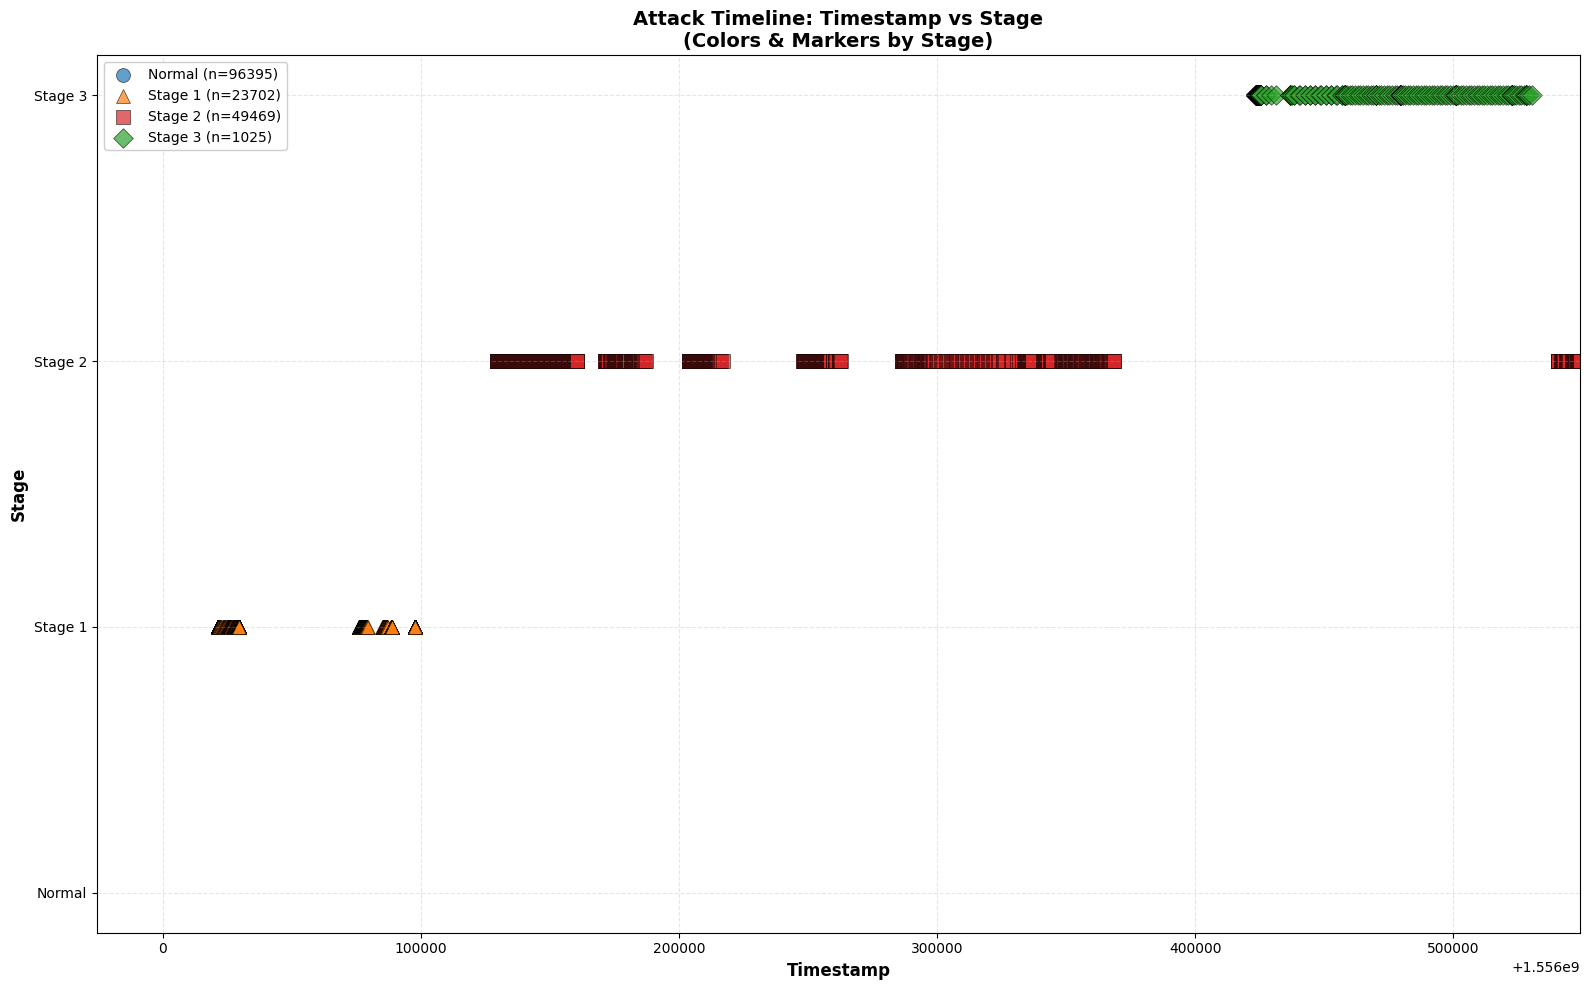


Visualization Summary:
  Total events: 170591
  Timestamp range: 1554198358 to 1556549129
  Display range: 1555974395 to 1556549129
  Stage distribution:
    Normal:  96395 ( 56.5%)
    Stage 1:  23702 ( 13.9%)
    Stage 2:  49469 ( 29.0%)
    Stage 3:   1025 (  0.6%)


In [108]:
# Temporal-Stage Dot Graph: Timestamp vs Stage (marked & colored by Stage)
df_plot = df.dropna(subset=['ts']).copy()

# Map stages to colors, markers, and names
stage_colors = {0: '#1f77b4', 1: '#ff7f0e', 2: '#d62728', 3: '#2ca02c'}  # blue, orange, red, green
stage_names = {0: 'Normal', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'}
stage_markers = {0: 'o', 1: '^', 2: 's', 3: 'D'}  # circle, triangle, square, diamond

# Find timestamp limits: start just before first non-normal stage
first_stage_ts = df_plot[df_plot['stage'] > 0]['ts'].min()
ts_margin = (df_plot['ts'].max() - df_plot['ts'].min()) * 0.02  # 2% margin
ts_start = first_stage_ts - ts_margin if first_stage_ts else df_plot['ts'].min()
ts_end = df_plot['ts'].max()

# Create figure
fig, ax = plt.subplots(figsize=(16, 10))

# Plot each stage separately for legend
for stage in sorted(df_plot['stage'].unique()):
    stage_data = df_plot[df_plot['stage'] == stage]
    ax.scatter(stage_data['ts'], stage_data['stage'], 
               c=stage_colors[stage], 
               marker=stage_markers[stage],
               s=100, alpha=0.7, 
               label=f'{stage_names[stage]} (n={len(stage_data)})',
               edgecolors='black', linewidth=0.5)

# Configure axes
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Stage', fontsize=12, fontweight='bold')
ax.set_title('Attack Timeline: Timestamp vs Stage\n(Colors & Markers by Stage)', 
             fontsize=14, fontweight='bold')

# Set Y-axis ticks and labels to stages
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels([stage_names[s] for s in [0, 1, 2, 3]])

# Set X-axis limits
ax.set_xlim(ts_start, ts_end)

# Format X-axis
ax.ticklabel_format(style='plain', axis='x')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

# Legend
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.savefig('timeline_stage_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization Summary:")
print(f"  Total events: {len(df_plot)}")
print(f"  Timestamp range: {df_plot['ts'].min():.0f} to {df_plot['ts'].max():.0f}")
print(f"  Display range: {ts_start:.0f} to {ts_end:.0f}")
print(f"  Stage distribution:")
for s in [0, 1, 2, 3]:
    count = (df_plot['stage'] == s).sum()
    pct = 100 * count / len(df_plot)
    print(f"    {stage_names[s]}: {count:>6} ({pct:>5.1f}%)")

In [109]:
df[df['stage']== 3]['ts'].median()

1556424163.0

In [110]:
len(df)

170591

---
## 2. DATA  PREPROCESSING

In [111]:
DROP_COLS_PRESPLIT = [ 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'http_referrer', 'sequence_type',
    'src_ip_bytes',
]
remaining = [c for c in df.columns if c not in DROP_COLS_PRESPLIT]
print(f"Presplit Features ({len(remaining)}): {remaining}")

DROP_COLS_AFTERSPLIT = [
    # Presplit features
    'src_ip', 'ts',    
    
    # label derivatives
    'type', 'label'
    ]

rem = [c for c in df.columns if c not in DROP_COLS_AFTERSPLIT and c not in DROP_COLS_PRESPLIT]
print(f"After-split Features ({len(rem)}): {rem}") 




Presplit Features (19): ['ts', 'src_ip', 'dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'label', 'type', 'stage']
After-split Features (15): ['dst_ip', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'stage']


### 2.1. Feature Engineering

In [112]:
def feature_engineering (df):
    ret = df.copy()
    # Per-flow features (safe for IP-split)
    ret['is_RSTOS0'] = (ret['conn_state'] == 'RSTOS0').astype(int)
    ret['is_tcp'] = (ret['proto'] == 'tcp').astype(int)
    ret['is_no_service'] = (ret['service'] == '-').astype(int)
    ret['is_no_response'] = ((ret['dst_bytes'] == 0) & (ret['dst_pkts'] == 0)).astype(int)
    return ret

def get_dummies (df):
    ret = df.copy()
    # Identify categorical columns (exclude src_ip, dst_ip, stage, and numeric columns)
    categorical_cols = [c for c in ret.columns 
                       if ret[c].dtype == 'object' and c not in ['src_ip', 'dst_ip', 'stage', 'type', 'label']]
    
    # One-hot encode only the categorical columns, preserving IPs
    if categorical_cols:
        ret = pd.get_dummies(ret, columns=categorical_cols, drop_first=True, dtype=int)
    
    return ret

def feature_selection_presplit (df, drop_cols=DROP_COLS_PRESPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')

def feature_selection_aftersplit (df, drop_cols=DROP_COLS_AFTERSPLIT):
    ret = df.copy()
    return ret.drop(columns=drop_cols, errors='ignore')


## 3. DATA SPLITTING

### 3.1. TIME SPLITTING WITH FLOW-AWARE SPLIT


In [113]:
def timesplit(df):
    df_temporal = df.dropna(subset=['ts']).copy()

    cutoff = df_temporal[df_temporal['stage']== 3]['ts'].median()

    df_future = df_temporal[df_temporal['ts'] >= cutoff].copy()
    df_past = df_temporal[df_temporal['ts'] < cutoff].copy()

#THEORETICALLY THE CODE BELOW IS DONE SO THAT NO src_ip in the future set is present in the past set, to prevent data leakage. However, in practice, this reduces the future set size drastically (since many src_ip appear in both sets), and it doesn't seem to improve model performance. So I'm commenting it out for now, but it can be re-enabled if needed.
    # unique_src_future = set(df_future['src_ip'].unique())
    # unique_src_past = set(df_past['src_ip'].unique())

    # overlap_ips = unique_src_future & unique_src_past  # IPs in both past and future

    # df_future = df_future[~df_future['src_ip'].isin(overlap_ips)].copy()

    print(f"Cutoff timestamp : {cutoff:.0f}")
    print(f"df_past rows     : {len(df_past)}")
    print(f"df_future rows   : {len(df_future)}")
    print(f"Stage 3 in past  : {(df_past['stage'] == 3).sum()}")
    print(f"Stage 3 in future: {(df_future['stage'] == 3).sum()}")

    return df_past, df_future

# df_past , df_future = timesplit(df)


---
### 3.2. Type-Aware IP Split (NEW)

### Problem v2/v3:
IP split per-stage bisa menempatkan seluruh attack type di satu set:
- Train Stage 2: 2 IP → hanya injection, xss, dos, ddos
- Test Stage 2: 10 IP → password, mitm, dll → **gak pernah dilihat model**

### Solusi:
Split per **attack type**, bukan per stage:
1. Untuk setiap unique `type`, kumpulkan semua `src_ip` yang melakukannya
2. Untuk setiap type, pastikan minimal 1 IP masuk test DAN sisanya di train
3. IP "whale" (>30% rows dari type itu) wajib train
4. Ini menjamin SETIAP attack type ada di train DAN test

In [114]:
def type_aware_ip_split(df, test_ratio=0.3, test_ratio_stage_3 = 0.5, random_state=42, verbose=True):
    """
    Type-Aware IP Split: Ensures every attack type is represented in both train and test.
    
    Parameters:
    -----------
    df : DataFrame
        Input data with columns: 'src_ip', 'type', 'stage'
    test_ratio : float
        Target ratio of flows in test set (default 0.3)
    test_ratio_stage_3 : float
        Target ratio of flows in test set for stage 3 (default 0.5)
    random_state : int
        Random seed for reproducibility (default 42)
    verbose : bool
        Print detailed split information (default True)
    
    Returns:
    --------
    df_train, df_test : DataFrames
        Train and test splits with no overlapping IPs
    """
    rng = np.random.RandomState(random_state)
    test_ips = set()
    train_ips = set()
    
    if verbose:
        print("=" * 60)
        print("TYPE-AWARE IP SPLIT")
        print("=" * 60)

    # ── Step 1: Per attack type, split IPs ──────────────────────
    attack_types = [t for t in df['type'].unique() if t != 'normal']

    for atype in sorted(attack_types):
        type_df = df[df['type'] == atype]
        type_total = len(type_df)
        target_test = int(test_ratio * type_total)
        if atype in ['backdoor', 'ransomware']:
            target_test = int(test_ratio_stage_3 * type_total)
        
        ip_counts = type_df['src_ip'].value_counts().reset_index()
        ip_counts.columns = ['src_ip', 'flow_count']
        
        if atype not in ['backdoor', 'ransomware']:
            # Whale filtering: IP dengan >30% dari type ini → wajib train
            whale_threshold = 0.3 * type_total
            whales = ip_counts[ip_counts['flow_count'] > whale_threshold]
            small_fish = ip_counts[ip_counts['flow_count'] <= whale_threshold]
            
            # Whale IPs → train
            for wip in whales['src_ip']:
                train_ips.add(wip)
            
            # Dari small fish, pilih IPs untuk test
            shuffled = small_fish.sample(frac=1, random_state=rng).reset_index(drop=True)
            cur = 0; selected = []
            for _, row in shuffled.iterrows():
                if row['src_ip'] in train_ips:
                    continue
                if cur + row['flow_count'] <= target_test * 1.2:
                    selected.append(row['src_ip'])
                    cur += row['flow_count']
                if cur >= target_test * 0.8:
                    break
            
            # Fallback: kalau gak ada yang terpilih, ambil 1 small fish terkecil
            if not selected and len(small_fish) > 0:
                for _, row in small_fish.sort_values('flow_count').iterrows():
                    if row['src_ip'] not in train_ips:
                        selected.append(row['src_ip'])
                        cur += row['flow_count']
                        break
            
            test_ips.update(selected)
            if verbose:
                print(f"  {atype:12s}: {type_total:>6} flows | Whales: {len(whales)} | "
                    f"Test IPs: {len(selected)} ({cur} flows)")

    # ── Step 2: Normal-only IPs ─────────────────────────────────
    all_attack_ips = set(df[df['stage'] != 0]['src_ip'].unique())
    pure_normal = df[(df['stage'] == 0) & (~df['src_ip'].isin(all_attack_ips))]
    normal_target = int(test_ratio * len(pure_normal))

    nip = pure_normal['src_ip'].value_counts().reset_index()
    nip.columns = ['src_ip', 'flow_count']
    sn = nip[nip['flow_count'] <= normal_target].sample(frac=1, random_state=rng)
    c = 0; sel_n = []
    for _, row in sn.iterrows():
        if c + row['flow_count'] <= normal_target * 1.1:
            sel_n.append(row['src_ip']); c += row['flow_count']
        if c >= normal_target * 0.9: break
    test_ips.update(sel_n)
    if verbose:
        print(f"  {'normal':12s}: {len(pure_normal):>6} flows | Test IPs: {len(sel_n)} ({c} flows)")

    # ── Step 3: Enforce no-overlap ──────────────────────────────
    test_ips -= train_ips

    # ── Step 4: Split ───────────────────────────────────────────
    df_train = df[~df['src_ip'].isin(test_ips)].copy()
    df_test = df[df['src_ip'].isin(test_ips)].copy()

    if verbose:
        print(f"\nTrain: {len(df_train)} ({df_train['src_ip'].nunique()} IPs)")
        print(f"Test:  {len(df_test)} ({df_test['src_ip'].nunique()} IPs)")
        print(f"IP overlap: {len(set(df_train['src_ip']) & set(df_test['src_ip']))}")

        # ── Validation: every type in both sets ─────────────────────
        print(f"\nType coverage validation:")
        all_ok = True
        for atype in sorted(attack_types):
            in_train = len(df_train[df_train['type'] == atype])
            in_test = len(df_test[df_test['type'] == atype])
            status = "OK" if (in_train > 0 and in_test > 0) else "MISSING!"
            if in_train == 0 or in_test == 0:
                all_ok = False
            print(f"  {atype:12s}: train={in_train:>6}, test={in_test:>5}  [{status}]")

        if all_ok:
            print("\n  ALL TYPES present in both train and test!")
        else:
            print("\n  WARNING: Some types missing from train or test")

        print(f"\nStage distribution:")
        for s in [0, 1, 2, 3]:
            tr = (df_train['stage']==s).sum(); te = (df_test['stage']==s).sum()
            print(f"  Stage {s}: train={tr:>6}, test={te:>6}")

    return df_train, df_test


# # Execute the split
# df_train_past, df_test_past = type_aware_ip_split(df_past, test_ratio=0.3, test_ratio_stage_3=0.5, random_state=42, verbose=True)

---
# DATA PIPELINE

## 4. DATA PREPROCESSING EXECUTION

In [115]:
df.columns

Index(['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_referrer', 'http_version',
       'http_request_body_len', 'http_response_body_len', 'http_status_code',
       'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types',
       'weird_name', 'weird_addl', 'weird_notice', 'label', 'type', 'stage',
       'sequence_type'],
      dtype='object')

In [116]:
# Data Preprocessing
df = feature_engineering(df)
df = get_dummies(df)
df = feature_selection_presplit(df)

# Execute Time Split
df_past , df_future = timesplit(df)

# Execute IP Split
df_train_past, df_test_past = type_aware_ip_split(df_past, test_ratio=0.3, test_ratio_stage_3=0.5, random_state=42, verbose=True)

df_past, df_future = feature_selection_aftersplit(df_past), feature_selection_aftersplit(df_future)
df_train_past, df_test_past = feature_selection_aftersplit(df_train_past), feature_selection_aftersplit(df_test_past)

Cutoff timestamp : 1556424163
df_past rows     : 169776
df_future rows   : 815
Stage 3 in past  : 510
Stage 3 in future: 515
TYPE-AWARE IP SPLIT
  ddos        :   2047 flows | Whales: 1 | Test IPs: 2 (628 flows)
  dos         :  14547 flows | Whales: 1 | Test IPs: 2 (1728 flows)
  injection   :  16310 flows | Whales: 1 | Test IPs: 7 (982 flows)
  password    :   1034 flows | Whales: 2 | Test IPs: 3 (105 flows)
  scanning    :  23702 flows | Whales: 1 | Test IPs: 17 (4930 flows)
  xss         :  15231 flows | Whales: 1 | Test IPs: 2 (6 flows)
  normal      :  83014 flows | Test IPs: 48 (22850 flows)

Train: 135850 (20 IPs)
Test:  33926 (67 IPs)
IP overlap: 0

Type coverage validation:
  ddos        : train=  1767, test=  280  [OK]
  dos         : train= 12819, test= 1728  [OK]
  injection   : train= 15336, test=  974  [OK]
  password    : train=   929, test=  105  [OK]
  ransomware  : train=   269, test=  241  [OK]
  scanning    : train= 18772, test= 4930  [OK]
  xss         : train= 15

In [117]:
# Run this BEFORE calling the function
print(f"df_future shape  : {df_future.shape}")
print(f"df_test_past shape: {df_test_past.shape}")
print(f"df_future columns: {list(df_future.columns[:10])} ...")



df_future shape  : (815, 402)
df_test_past shape: (33926, 402)
df_future columns: ['dst_ip', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype'] ...



## Helper Functions

In [118]:

def find_optimal_threshold(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, y_proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-8)
    bi = np.argmax(f1s)
    bt = thresh[bi] if bi < len(thresh) else 0.5
    print(f"  Optimal threshold: {bt:.4f} (F1={f1s[bi]:.4f})")
    fig,(a1,a2) = plt.subplots(1,2,figsize=(12,4))
    a1.plot(rec,prec,'b-',lw=1.5); a1.set_xlabel('Recall'); a1.set_ylabel('Precision')
    a1.set_title(f'{name} PR Curve'); a1.grid(True,alpha=0.3)
    a2.plot(thresh,f1s[:-1],'g-',lw=1.5)
    a2.axvline(x=bt,color='r',ls='--',alpha=0.7,label=f't={bt:.3f}')
    a2.set_xlabel('Threshold'); a2.set_ylabel('F1'); a2.set_title(f'{name} F1 vs t')
    a2.legend(); a2.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
    return bt, y_proba

def evaluate_stage(y_true, y_pred, name):
    prec,rec,f1,_ = precision_recall_fscore_support(y_true,y_pred,average='binary',zero_division=0)
    cm = confusion_matrix(y_true,y_pred); tn,fp,fn,tp = cm.ravel()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
    return {'f1':f1,'precision':prec,'recall':rec,'fpr':fpr,'cm':cm}


print("Functions defined.")

Functions defined.


# DETECTION MODELS

## 5. Prepare Training vs Testing Data for Stage 1 and Stage 2

In [119]:
def prepare_Xy(train_data, test_data, stage_num):
    y_train = (train_data['stage'] == stage_num).astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = (test_data['stage'] == stage_num).astype(int)
    train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)
    X_train = train_data.drop(columns=['stage', 'dst_ip'], errors='ignore')
    X_test = test_data.drop(columns=['stage', 'dst_ip'], errors='ignore')
    return X_train, X_test, y_train, y_test

---
## 6. Stage 1 — Reconnaissance

In [120]:

X_tr1,X_te1,y_tr1,y_te1 = prepare_Xy(df_train_past,df_test_past,1)
print(f"Train: {len(X_tr1)} | Test: {len(X_te1)}")

rf_s1 = RandomForestClassifier(n_estimators=300,max_depth=25,min_samples_split=5,
    min_samples_leaf=2,class_weight='balanced',random_state=42,n_jobs=-1)
print("Training..."); rf_s1.fit(X_tr1,y_tr1)

y_p1 = rf_s1.predict(X_te1)

print("\n--- Default ---")
results_s1 = evaluate_stage(y_te1,y_p1,"Stage 1 default")
print(classification_report(y_te1,y_p1,target_names=['Other','Stage 1']))


Train: 135850 | Test: 33926
Training...

--- Default ---

Stage 1 default
F1=0.8422  Prec=0.7578  Rec=0.9477  FPR=0.0515
TN=27503 FP=1493 FN=258 TP=4672
              precision    recall  f1-score   support

       Other       0.99      0.95      0.97     28996
     Stage 1       0.76      0.95      0.84      4930

    accuracy                           0.95     33926
   macro avg       0.87      0.95      0.91     33926
weighted avg       0.96      0.95      0.95     33926



### 6.1 Learning Curve

---
## 7. Stage 2 — Privilege Escalation (full data)

In [121]:
X_tr2,X_te2,y_tr2,y_te2 = prepare_Xy(df_train_past,df_test_past,2)
print(f"Train: {len(X_tr2)} (S2={y_tr2.sum()}) | Test: {len(X_te2)} (S2={y_te2.sum()})")

rf_s2 = RandomForestClassifier(n_estimators=200,max_depth=20,min_samples_split=5,
    min_samples_leaf=2,class_weight='balanced',random_state=42,n_jobs=-1)
print("\nTraining..."); rf_s2.fit(X_tr2,y_tr2)
y_p2 = rf_s2.predict(X_te2)

results_s2 = evaluate_stage(y_te2,y_p2,"Stage 2")
print(classification_report(y_te2,y_p2,target_names=['Other','Stage 2']))

Train: 135850 (S2=46076) | Test: 33926 (S2=3093)

Training...

Stage 2
F1=0.6549  Prec=0.8990  Rec=0.5150  FPR=0.0058
TN=30654 FP=179 FN=1500 TP=1593
              precision    recall  f1-score   support

       Other       0.95      0.99      0.97     30833
     Stage 2       0.90      0.52      0.65      3093

    accuracy                           0.95     33926
   macro avg       0.93      0.75      0.81     33926
weighted avg       0.95      0.95      0.94     33926



---
## 10. Confusion Matrices

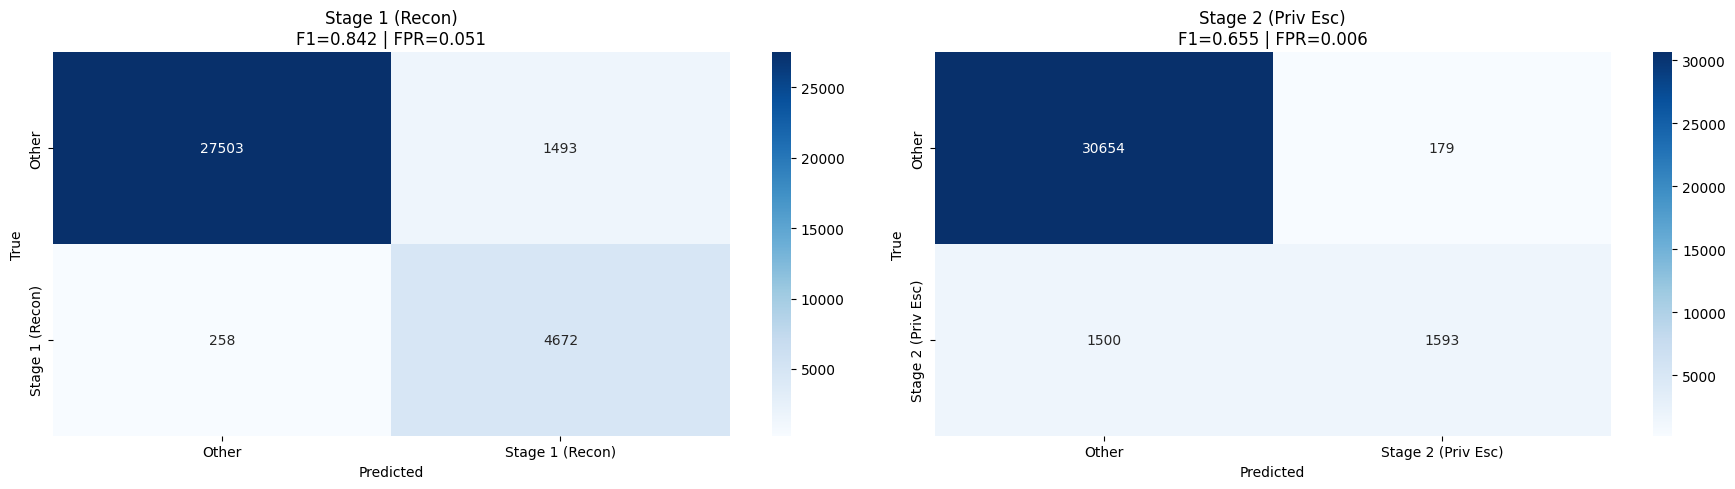

In [122]:
fig,axes = plt.subplots(1,2,figsize=(18,5))
for ax,lbl,res in zip(axes,
    ['Stage 1 (Recon)','Stage 2 (Priv Esc)'],
    [results_s1,results_s2]):
    sns.heatmap(res['cm'],annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=['Other',lbl],yticklabels=['Other',lbl])
    ax.set_title(f"{lbl}\nF1={res['f1']:.3f} | FPR={res['fpr']:.3f}")
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrices_v3.png',dpi=150,bbox_inches='tight')
plt.show()

---
## 11. Feature Importance

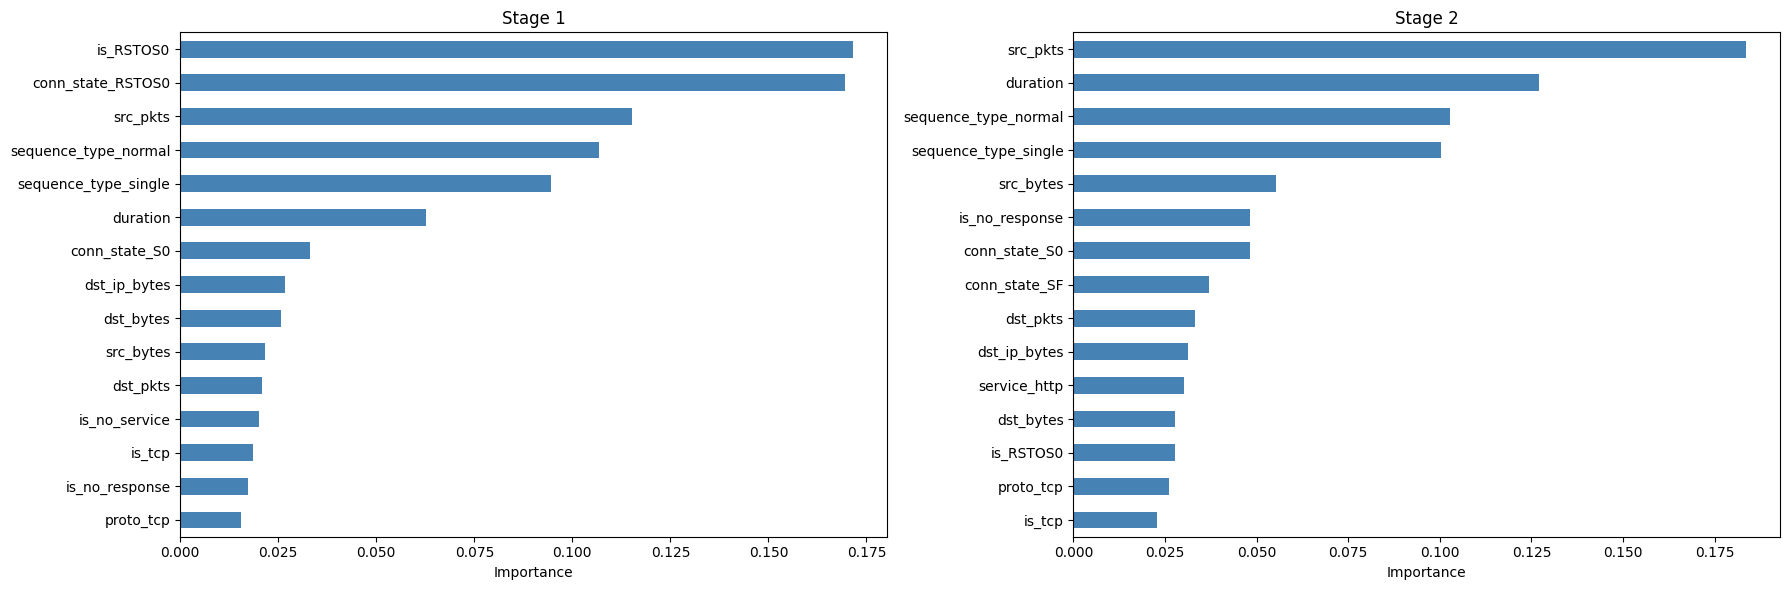

In [123]:
fig,axes = plt.subplots(1,2,figsize=(18,6))
for ax,m,X,t in zip(axes,[rf_s1,rf_s2],[X_tr1,X_tr2],
    ['Stage 1','Stage 2']):
    imp = pd.Series(m.feature_importances_,index=X.columns).nlargest(15)
    imp.plot(kind='barh',ax=ax,color='steelblue')
    ax.set_title(t); ax.set_xlabel('Importance'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_v3.png',dpi=150,bbox_inches='tight')
plt.show()

# PREDICTION SETUP
---

## 12. Dataset creation

In [124]:


def aggregate_by_dst_ip(dftest,stage_num=3):
    # Aggregate by destination IP using actual columns
    agg_dict = {}

    # Identify numeric and categorical columns
    numeric_cols = []
    categorical_cols = []
    for col in dftest.columns:
        if col != 'dst_ip':
            if dftest[col].dtype in ['int64', 'float64'] and col != 'stage':
                numeric_cols.append(col)
                agg_dict[col] = ['count', 'sum', 'mean', 'min', 'max', 'std']
            elif col == 'stage':
                    # For 'stage', we can do a specific aggregation to count occurrences of each stage
                    agg_dict[col] = lambda x: 1 if (x == stage_num).any() else 0  # Return 1 if stage exists, 0 otherwise
            else:
                categorical_cols.append(col)

    # First aggregation for numeric columns
    dftest_agg = dftest.groupby('dst_ip').agg(agg_dict)

    # Flatten numeric column names (keep 'stage' as is)
    dftest_agg.columns = ['stage' if col[0] == 'stage' else '_'.join(col).strip() for col in dftest_agg.columns.values]


    # Now handle categorical columns with value counts as dummies
    for cat_col in categorical_cols:
        # Get value counts grouped by dst_ip
        value_counts_by_ip = dftest.groupby(['dst_ip', cat_col]).size().unstack(fill_value=0)
        # Rename columns as [ORIGINAL_COL]_[Value]_count
        value_counts_by_ip.columns = [f"{cat_col}_{val}_count" for val in value_counts_by_ip.columns]
        # Add to aggregation result
        dftest_agg = dftest_agg.join(value_counts_by_ip)

    # Round numeric columns and sort
    dftest_agg = dftest_agg.round(4)
    return dftest_agg


# def prepare_dataset(train_data = df_test_past, test_data = df_future, stage_num = 3):

#     # past_proba_enriched = train_data.copy()
#     # future_proba_enriched = test_data.copy()


#     # print(stage_det_adj_test_past.columns)
#     # x_tr_adj_1, x_te_adj_1, a, b= prepare_Xy(stage_det_adj_test_past, stage_det_adj_future, stage_num = 1)
#     # x_tr_adj_2, x_te_adj_2, c, d= prepare_Xy(stage_det_adj_test_past, stage_det_adj_future, stage_num = 2)
#     # print(x_tr_adj_1.columns)

#     # train_data ['stage_1_proba'] = rf_s1.predict_proba(x_tr_adj_1)[:,1]
#     # test_data['stage_1_proba'] = rf_s1.predict_proba(x_te_adj_1)[:,1]
#     # train_data['stage_2_proba'] = rf_s2.predict_proba(x_tr_adj_2)[:,1]
#     # test_data['stage_2_proba'] = rf_s2.predict_proba(x_te_adj_2)[:,1]

#     # drop = [c for c in DROP_COLS_PRED if c in train_data.columns]
#     # train_data = train_data.drop(columns=drop, errors='ignore')
#     # test_data = test_data.drop(columns=drop, errors='ignore')

#     # train_agg = aggregate_by_dst_ip(train_data, stage_num)
#     # test_agg = aggregate_by_dst_ip(test_data, stage_num)

#     # ── Stage 3 dataset construction ────────────────────────────────────────────
# # test_past doubles as: (a) test set for S1/S2 models, (b) train set for S3
# # We need:  dst_ip (for IP-level aggregation)  +  predict_proba from rf_s1, rf_s2
# # Strategy: keep dst_ip in the DataFrame throughout; only drop it from the
# #           feature matrix (X) before calling predict_proba.

# # 1. Make a working copy of test_past that still has dst_ip
# #    (feature_selection_detection already dropped src_ip, ts, type, label
# #     but kept dst_ip because dst_ip is NOT in DROP_COLS_DETECTION)

# assert 'dst_ip' in df_test_past.columns, "dst_ip was dropped too early!"

# test_past_enriched  = df_test_past.copy()
# future_enriched     = df_future.copy()

# # 2. Build feature matrices for S1 / S2 (must align columns & drop dst_ip + stage)
# NON_FEATURE_COLS = ['dst_ip', 'stage']

# def make_X(df, reference_cols):
#     """Drop non-feature cols, align to reference, fill missing with 0."""
#     X = df.drop(columns=NON_FEATURE_COLS, errors='ignore')
#     X = X.reindex(columns=reference_cols, fill_value=0)
#     return X

# # Reference column order comes from the S1/S2 training sets
# ref_cols_s1 = X_tr1.columns   # set during Stage 1 training
# ref_cols_s2 = X_tr2.columns   # set during Stage 2 training

# X_te_past_s1 = make_X(test_past_enriched, ref_cols_s1)
# X_te_past_s2 = make_X(test_past_enriched, ref_cols_s2)

# X_te_future_s1 = make_X(future_enriched, ref_cols_s1)
# X_te_future_s2 = make_X(future_enriched, ref_cols_s2)

# # 3. Attach predict_proba columns (index-safe: both DFs unchanged)
# test_past_enriched['stage_1_proba'] = rf_s1.predict_proba(X_te_past_s1)[:, 1]
# test_past_enriched['stage_2_proba'] = rf_s2.predict_proba(X_te_past_s2)[:, 1]

# future_enriched['stage_1_proba']    = rf_s1.predict_proba(X_te_future_s1)[:, 1]
# future_enriched['stage_2_proba']    = rf_s2.predict_proba(X_te_future_s2)[:, 1]

# print(f"test_past_enriched shape : {test_past_enriched.shape}")
# print(f"future_enriched shape    : {future_enriched.shape}")
# print(f"Proba columns present    : {['stage_1_proba','stage_2_proba']}")
# print(f"dst_ip still present     : {test_past_enriched['dst_ip'].nunique()} unique IPs")

# # 4. Aggregate per dst_ip  →  one row per target entity
# #    aggregate_by_dst_ip groups by dst_ip, collapses all flow-level features
# #    into per-IP statistics, and sets the label = 1 if any S3 flow hit that IP
# train_agg = aggregate_by_dst_ip(test_past_enriched, stage_num=3)
# test_agg  = aggregate_by_dst_ip(future_enriched,    stage_num=3)






In [125]:
def build_stage3_dataset(df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2):
  """
  Build the Stage 3 entity underthreat dataset from test_past and future.

  test_past serves dual purpose:
    - Test set for Stage 1 & 2 detection models (predict_proba)
    - Training set for Stage 3 entity underthreat model (after aggregation)

  Parameters
  ----------
    df_test_past : DataFrame  — flow-level, still has dst_ip + stage
    df_future    : DataFrame  — flow-level, still has dst_ip + stage
    rf_s1        : trained Stage 1 RandomForestClassifier
    rf_s2        : trained Stage 2 RandomForestClassifier
    X_tr1        : training feature matrix used for rf_s1 (for column alignment)
    X_tr2        : training feature matrix used for rf_s2 (for column alignment)

  Returns
  -------
    X_tr3, X_te3, y_tr3, y_te3 : feature matrices and labels for Stage 3
    train_agg, test_agg        : aggregated DataFrames (index = dst_ip)
    """

  assert 'dst_ip' in df_test_past.columns, "dst_ip missing from df_test_past — was it dropped too early?"
  assert 'dst_ip' in df_future.columns,    "dst_ip missing from df_future — was it dropped too early?"

  NON_FEATURE_COLS = ['dst_ip', 'stage']

  def make_X(df, reference_cols):
      X = df.drop(columns=NON_FEATURE_COLS, errors='ignore')
      X = X.reindex(columns=reference_cols, fill_value=0)
      return X

  # 1. Working copies (preserve dst_ip)
  test_past_enriched = df_test_past.copy()
  future_enriched    = df_future.copy()

  # Reference column order comes from the S1/S2 training sets
  ref_cols_s1 = X_tr1.columns   # set during Stage 1 training
  ref_cols_s2 = X_tr2.columns   # set during Stage 2 training

  # 2. Build aligned feature matrices for S1 / S2
  X_te_past_s1   = make_X(test_past_enriched, ref_cols_s1)
  X_te_past_s2   = make_X(test_past_enriched, ref_cols_s2)
  X_te_future_s1 = make_X(future_enriched,    ref_cols_s1)
  X_te_future_s2 = make_X(future_enriched,    ref_cols_s2)

  # 3. Attach predict_proba columns
  test_past_enriched['stage_1_proba'] = rf_s1.predict_proba(X_te_past_s1)[:, 1]
  test_past_enriched['stage_2_proba'] = rf_s2.predict_proba(X_te_past_s2)[:, 1]
  future_enriched['stage_1_proba']    = rf_s1.predict_proba(X_te_future_s1)[:, 1]
  future_enriched['stage_2_proba']    = rf_s2.predict_proba(X_te_future_s2)[:, 1]

 # 4. Aggregate per dst_ip → one row per target entity
  train_agg = aggregate_by_dst_ip(test_past_enriched, stage_num=3)
  test_agg  = aggregate_by_dst_ip(future_enriched,    stage_num=3)

  print(f"\nStage 3 train_agg shape  : {train_agg.shape}  (one row per dst_ip)")
  print(f"Stage 3 test_agg shape   : {test_agg.shape}")
  print(f"Positive labels in train : {train_agg['stage'].sum()}")
  print(f"Positive labels in test  : {test_agg['stage'].sum()}")

  # 5. ── Align columns (train is reference, test fills missing with 0) ──────
  #    Keep 'stage' out of alignment — it's the label, not a feature
  label_col = 'stage'
  train_cols = [c for c in train_agg.columns if c != label_col]
    
  test_agg = test_agg.reindex(
    columns=train_cols + [label_col],
    fill_value=0
  )
    # Ensure train also has no extra cols (defensive)
  train_agg = train_agg.reindex(
    columns=train_cols + [label_col],
    fill_value=0
  )

  return train_agg, test_agg

In [126]:
df_future['stage'].value_counts().sort_index()

stage
2    300
3    515
Name: count, dtype: int64

In [127]:
def prepare_Xy_pred(train_data = df_test_past, test_data = df_future, stage_num = 3):
    y_train = train_data['stage'].astype(int)  #Output: Binary for a specific attack stage ("stage_num")
    y_test = test_data['stage'].astype(int)
    drop = 'stage'
    X_train = train_data.drop(columns=drop, errors='ignore')
    X_test = test_data.drop(columns=drop, errors='ignore')

    return X_train, X_test, y_train, y_test

In [128]:
# Execute the full Stage 3 dataset construction
train_agg, test_agg = build_stage3_dataset(
    df_test_past, df_future, rf_s1, rf_s2, X_tr1, X_tr2
)

# Split into X / y for the entity underthreat model
X_tr3, X_te3, y_tr3, y_te3 = prepare_Xy_pred(train_agg, test_agg, stage_num=3)

print(f"\nX_tr3: {X_tr3.shape} | y_tr3 positives: {y_tr3.sum()}")
print(f"X_te3: {X_te3.shape} | y_te3 positives: {y_te3.sum()}")
print(f"\nAll columns in train_agg ({len(train_agg.columns)}):")
for i, col in enumerate(train_agg.columns, 1):
    print(f"  {i:3d}. {col}")


Stage 3 train_agg shape  : (560, 762)  (one row per dst_ip)
Stage 3 test_agg shape   : (102, 494)
Positive labels in train : 3
Positive labels in test  : 13

X_tr3: (560, 761) | y_tr3 positives: 3
X_te3: (102, 761) | y_te3 positives: 13

All columns in train_agg (762):
    1. duration_count
    2. duration_sum
    3. duration_mean
    4. duration_min
    5. duration_max
    6. duration_std
    7. src_bytes_count
    8. src_bytes_sum
    9. src_bytes_mean
   10. src_bytes_min
   11. src_bytes_max
   12. src_bytes_std
   13. dst_bytes_count
   14. dst_bytes_sum
   15. dst_bytes_mean
   16. dst_bytes_min
   17. dst_bytes_max
   18. dst_bytes_std
   19. missed_bytes_count
   20. missed_bytes_sum
   21. missed_bytes_mean
   22. missed_bytes_min
   23. missed_bytes_max
   24. missed_bytes_std
   25. src_pkts_count
   26. src_pkts_sum
   27. src_pkts_mean
   28. src_pkts_min
   29. src_pkts_max
   30. src_pkts_std
   31. dst_pkts_count
   32. dst_pkts_sum
   33. dst_pkts_mean
   34. dst_pkts

X_tr3: (560, 761)  |  y_tr3 positives: 3 / 560
X_te3: (102, 761)  |  y_te3 positives: 13 / 102

Class ratio (neg:pos) in train = 185.7:1

Running RandomizedSearchCV (40 iterations × 5-fold CV)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV F1  : 0.0000
Best params : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': {0: 1, 1: 278}}

Optimal threshold: 0.0989  (F1=0.7857)

Stage 3 — default threshold (0.50)
F1=0.0000  Prec=0.0000  Rec=0.0000  FPR=0.0000
TN=89  FP=0  FN=13  TP=0
              precision    recall  f1-score   support

 Safe entity       0.87      1.00      0.93        89
Under threat       0.00      0.00      0.00        13

    accuracy                           0.87       102
   macro avg       0.44      0.50      0.47       102
weighted avg       0.76      0.87      0.81       102


Stage 3 — optimal threshold (0.0989)
F1=0.7857  Prec=0.7333  Rec=0.8462  FPR=0.0449
TN

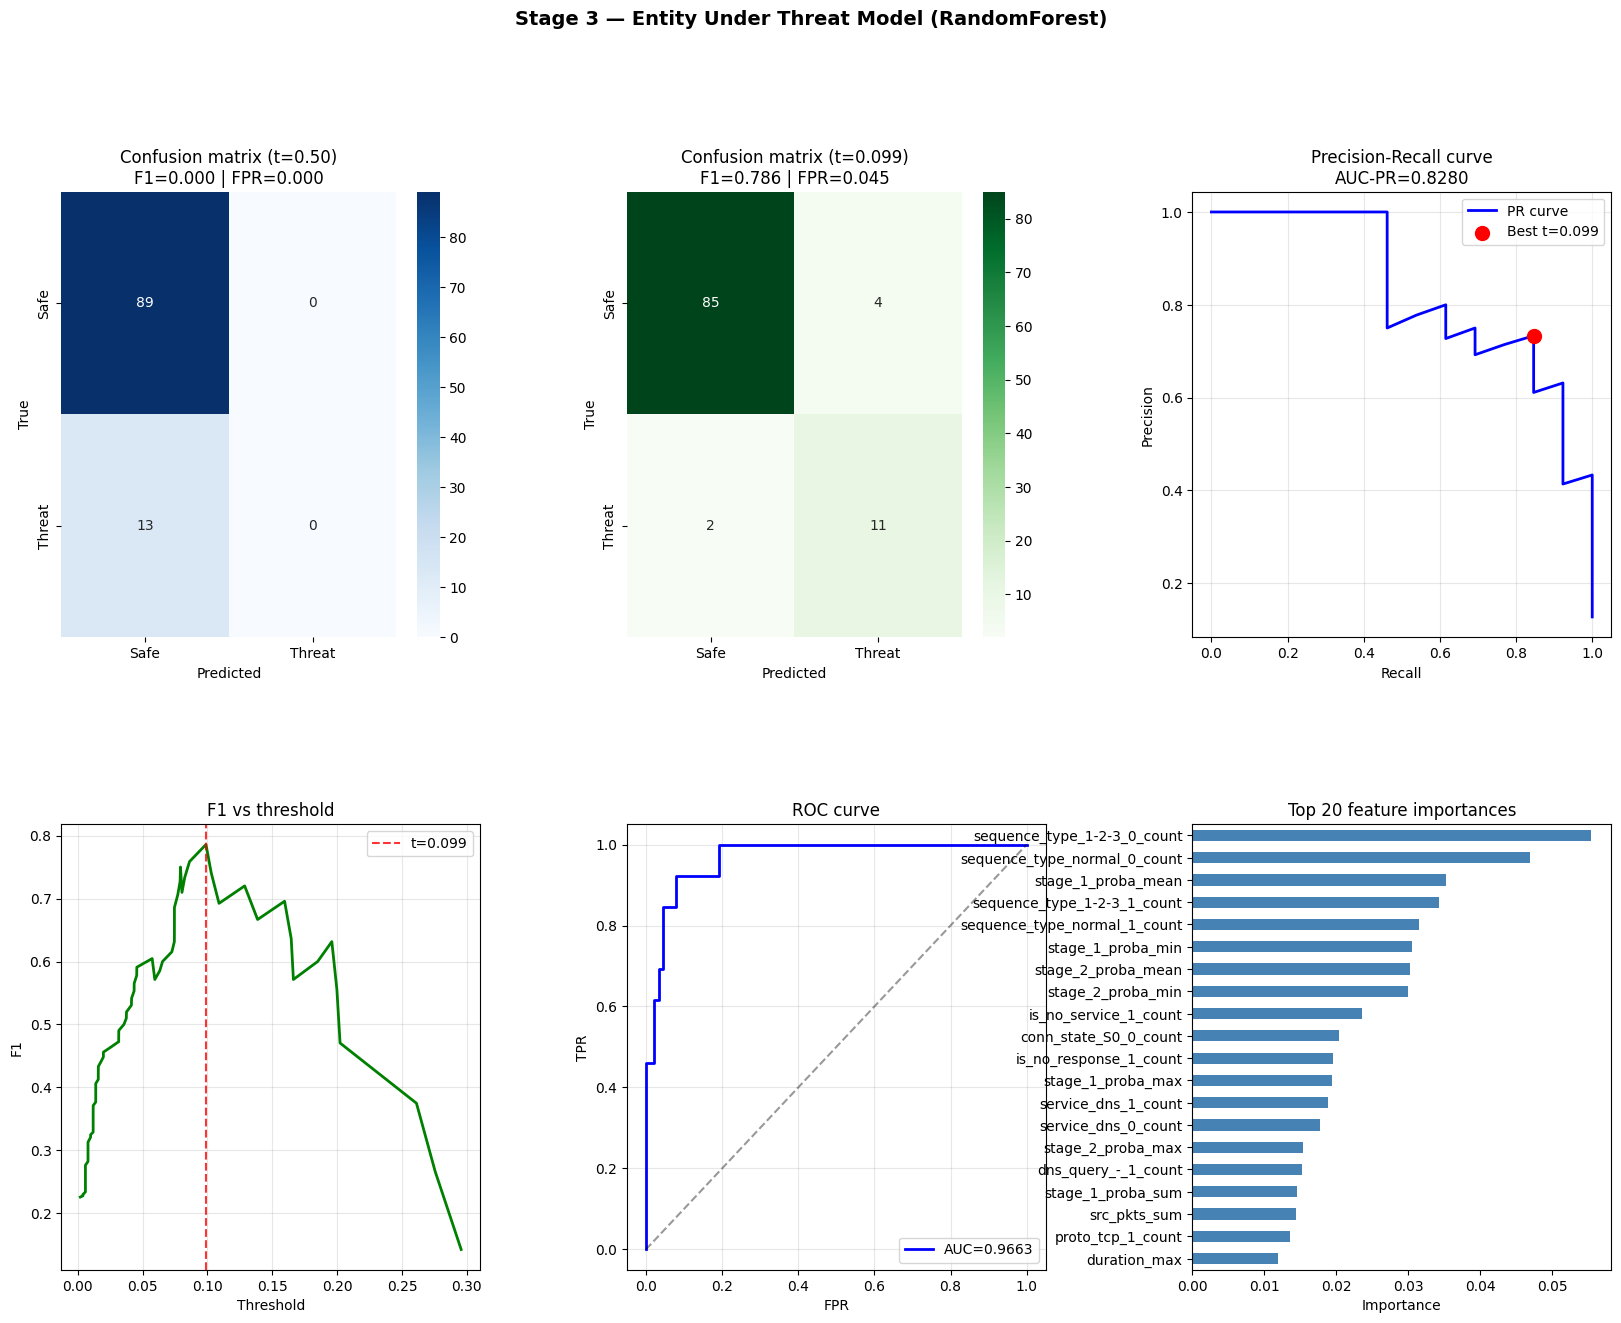


STAGE 3 SUMMARY
  Best hyperparams : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': {0: 1, 1: 278}}
  CV F1 (train)    : 0.0000
  Test F1 (t=0.50) : 0.0000
  Test F1 (t=0.099) : 0.7857
  AUC-ROC          : 0.9663
  AUC-PR           : 0.8280
  Test entities    : 102 | Threat: 13 | Safe: 89


In [131]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — ENTITY UNDER THREAT MODEL (RandomForest + RandomizedSearchCV)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_recall_fscore_support)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── 1. Sanity check ───────────────────────────────────────────────────────────
print(f"X_tr3: {X_tr3.shape}  |  y_tr3 positives: {int(y_tr3.sum())} / {len(y_tr3)}")
print(f"X_te3: {X_te3.shape}  |  y_te3 positives: {int(y_te3.sum())} / {len(y_te3)}")
assert y_tr3.sum() > 0, "No positives in training — check prepare_Xy_pred fix"
assert y_te3.sum() > 0, "No positives in test — check prepare_Xy_pred fix"

# ── 2. Class imbalance ratio (used for scale_pos_weight guidance) ─────────────
neg_tr, pos_tr = (y_tr3 == 0).sum(), (y_tr3 == 1).sum()
imbalance_ratio = neg_tr / pos_tr
print(f"\nClass ratio (neg:pos) in train = {imbalance_ratio:.1f}:1")

# ── 3. Hyperparameter search space ───────────────────────────────────────────
param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'class_weight'     : ['balanced', 'balanced_subsample',
                          {0: 1, 1: int(imbalance_ratio)},
                          {0: 1, 1: int(imbalance_ratio * 1.5)}],
}

# Stratified CV — critical for imbalanced entity-level data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1',          # optimise for minority-class F1
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("\nRunning RandomizedSearchCV (40 iterations × 5-fold CV)...")
search.fit(X_tr3, y_tr3)

print(f"\nBest CV F1  : {search.best_score_:.4f}")
print(f"Best params : {search.best_params_}")

rf_s3 = search.best_estimator_

# ── 4. Default threshold predictions ──────────────────────────────────────────
y_proba_s3 = rf_s3.predict_proba(X_te3)[:, 1]
y_pred_s3  = rf_s3.predict(X_te3)

# ── 5. Optimal threshold via PR curve ────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te3, y_proba_s3)
f1_arr  = 2 * (prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-8)
best_idx   = np.argmax(f1_arr)
best_thresh = thresh_arr[best_idx] if best_idx < len(thresh_arr) else 0.5

print(f"\nOptimal threshold: {best_thresh:.4f}  (F1={f1_arr[best_idx]:.4f})")
y_pred_opt = (y_proba_s3 >= best_thresh).astype(int)

# ── 6. Evaluation helper (reuses notebook style) ─────────────────────────────
def eval_s3(y_true, y_pred, label):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    print(f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  FPR={fpr:.4f}")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(classification_report(y_true, y_pred,
          target_names=['Safe entity', 'Under threat'], zero_division=0))
    return {'f1': f1, 'precision': prec, 'recall': rec, 'fpr': fpr, 'cm': cm,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

results_s3_default = eval_s3(y_te3, y_pred_s3,  "Stage 3 — default threshold (0.50)")
results_s3_opt     = eval_s3(y_te3, y_pred_opt,  f"Stage 3 — optimal threshold ({best_thresh:.4f})")

# ── 7. Figures ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 7a. Confusion matrix — default threshold
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(results_s3_default['cm'], annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax1.set_title(f"Confusion matrix (t=0.50)\nF1={results_s3_default['f1']:.3f} | FPR={results_s3_default['fpr']:.3f}")
ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

# 7b. Confusion matrix — optimal threshold
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(results_s3_opt['cm'], annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=['Safe', 'Threat'], yticklabels=['Safe', 'Threat'])
ax2.set_title(f"Confusion matrix (t={best_thresh:.3f})\nF1={results_s3_opt['f1']:.3f} | FPR={results_s3_opt['fpr']:.3f}")
ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')

# 7c. PR curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(rec_arr, prec_arr, 'b-', lw=2, label='PR curve')
ax3.scatter(rec_arr[best_idx], prec_arr[best_idx],
            color='red', s=100, zorder=5, label=f'Best t={best_thresh:.3f}')
pr_auc = auc(rec_arr, prec_arr)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Precision-Recall curve\nAUC-PR={pr_auc:.4f}')
ax3.legend(); ax3.grid(True, alpha=0.3)

# 7d. F1 vs threshold
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(thresh_arr, f1_arr[:-1], 'g-', lw=2)
ax4.axvline(x=best_thresh, color='r', ls='--', alpha=0.8, label=f't={best_thresh:.3f}')
ax4.set_xlabel('Threshold'); ax4.set_ylabel('F1')
ax4.set_title('F1 vs threshold'); ax4.legend(); ax4.grid(True, alpha=0.3)

# 7e. ROC curve
fpr_roc, tpr_roc, _ = roc_curve(y_te3, y_proba_s3)
roc_auc_score = auc(fpr_roc, tpr_roc)
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(fpr_roc, tpr_roc, 'b-', lw=2, label=f'AUC={roc_auc_score:.4f}')
ax5.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax5.set_xlabel('FPR'); ax5.set_ylabel('TPR')
ax5.set_title('ROC curve'); ax5.legend(); ax5.grid(True, alpha=0.3)

# 7f. Feature importance (top 20)
ax6 = fig.add_subplot(gs[1, 2])
feat_imp = pd.Series(rf_s3.feature_importances_, index=X_tr3.columns).nlargest(20)
feat_imp.plot(kind='barh', ax=ax6, color='steelblue')
ax6.set_title('Top 20 feature importances')
ax6.set_xlabel('Importance'); ax6.invert_yaxis()

plt.suptitle('Stage 3 — Entity Under Threat Model (RandomForest)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('stage3_entity_underthreat_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 8. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("STAGE 3 SUMMARY")
print("="*60)
print(f"  Best hyperparams : {search.best_params_}")
print(f"  CV F1 (train)    : {search.best_score_:.4f}")
print(f"  Test F1 (t=0.50) : {results_s3_default['f1']:.4f}")
print(f"  Test F1 (t={best_thresh:.3f}) : {results_s3_opt['f1']:.4f}")
print(f"  AUC-ROC          : {roc_auc_score:.4f}")
print(f"  AUC-PR           : {pr_auc:.4f}")
print(f"  Test entities    : {len(y_te3)} | Threat: {int(y_te3.sum())} | Safe: {int((y_te3==0).sum())}")
